In [7]:
import pandas as pd

df = pd.read_csv("/Users/kuntalbanerjee/Downloads/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 21)

In [11]:
## total sales per customer

customer_sales = df.groupby("Customer Name")["Sales"].sum().reset_index()

customer_sales = customer_sales.sort_values(by="Sales", ascending=False)

customer_sales.head()

,Customer Name,Sales
686,Sean Miller,25043.050
730,Tamara Chand,19052.218
622,Raymond Buch,15117.339
757,Tom Ashbrook,14595.620
6,Adrian Barton,14473.571


In [13]:
## customer segments

customer_sales["Segment"] = pd.qcut(customer_sales["Sales"], 3,
                                    labels=["Low Value","Medium Value","High Value"])

customer_sales.head()

,Customer Name,Sales,Segment
686,Sean Miller,25043.050,High Value
730,Tamara Chand,19052.218,High Value
622,Raymond Buch,15117.339,High Value
757,Tom Ashbrook,14595.620,High Value
6,Adrian Barton,14473.571,High Value


In [15]:
##customers in each segment

segment_counts = customer_sales["Segment"].value_counts()

segment_counts

Segment
Low Value       265
Medium Value    264
High Value      264
Name: count, dtype: int64

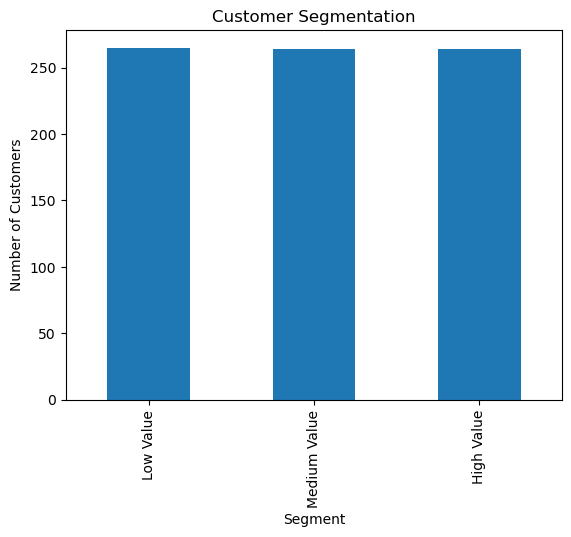

In [17]:
import matplotlib.pyplot as plt

segment_counts.plot(kind="bar")

plt.title("Customer Segmentation")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

In [19]:
customer_sales[customer_sales["Segment"] == "High Value"].head(10)

,Customer Name,Sales,Segment
686,Sean Miller,25043.050,High Value
730,Tamara Chand,19052.218,High Value
622,Raymond Buch,15117.339,High Value
757,Tom Ashbrook,14595.620,High Value
6,Adrian Barton,14473.571,High Value
441,Ken Lonsdale,14175.229,High Value
671,Sanjit Chand,14142.334,High Value
334,Hunter Lopez,12873.298,High Value
672,Sanjit Engle,12209.438,High Value
156,Christopher Conant,12129.072,High Value


In [21]:
## Revenue contribution by segment
segment_revenue = customer_sales.groupby("Segment")["Sales"].sum()

segment_revenue

/var/folders/x7/3htwmk654n5fs5q87bnjqn3h0000gn/T/ipykernel_27161/3456857007.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = customer_sales.groupby("Segment")["Sales"].sum()


Segment
Low Value       2.127111e+05
Medium Value    5.982392e+05
High Value      1.486251e+06
Name: Sales, dtype: float64